Task 1 – Data Preparation and the Sigmoid Function  (15 marks)

X: (2, 400)
Y: (1, 400)


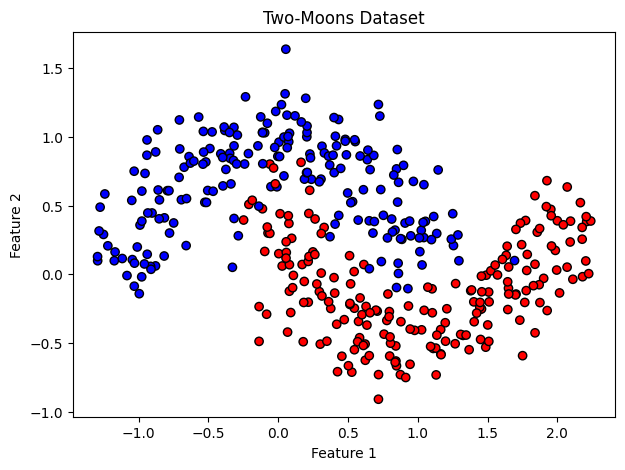

In [ ]:
# ============================================================
# TASK 1 - BLOCK 1
# Data Preparation
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X_raw, y_raw = make_moons(
    n_samples=400,
    noise=0.20,
    random_state=1
)

X = X_raw.T
Y = y_raw.reshape(1, -1)

print("X:", X.shape)
print("Y:", Y.shape)

plt.figure(figsize=(7, 5))
plt.scatter(
    X[0],
    X[1],
    c=Y.ravel(),
    cmap="bwr",
    edgecolors="k"
)
plt.title("Two-Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
# ============================================================
# TASK 1 - BLOCK 2
# Split into 320 Training and 80 Testing Examples
# ============================================================

np.random.seed(1)

indices = np.random.permutation(X.shape[1])

train_indices = indices[:320]
test_indices = indices[320:]

X_train = X[:, train_indices]
Y_train = Y[:, train_indices]

X_test = X[:, test_indices]
Y_test = Y[:, test_indices]

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)

print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

assert X_train.shape == (2, 320)
assert Y_train.shape == (1, 320)

assert X_test.shape == (2, 80)
assert Y_test.shape == (1, 80)

X_train: (2, 320)
Y_train: (1, 320)
X_test: (2, 80)
Y_test: (1, 80)


In [ ]:
# ============================================================
# TASK 1 - BLOCK 3
# Stable Sigmoid Function
# ============================================================

def sigmoid(z):
    z = np.asarray(z, dtype=float)

    result = np.empty_like(z, dtype=float)

    positive = z >= 0
    negative = ~positive

    result[positive] = 1.0 / (1.0 + np.exp(-z[positive]))

    exp_z = np.exp(z[negative])
    result[negative] = exp_z / (1.0 + exp_z)

    if result.ndim == 0:
        return float(result)

    return result


print("sigmoid(0) =", sigmoid(0))
print("sigmoid(-1000) =", sigmoid(-1000))
print("sigmoid(1000) =", sigmoid(1000))

assert np.isclose(sigmoid(0), 0.5)
assert np.isfinite(sigmoid(-1000))
assert np.isfinite(sigmoid(1000))

sigmoid(0) = 0.5
sigmoid(-1000) = 0.0
sigmoid(1000) = 1.0


z_values shape: (500,)
sigmoid_values shape: (500,)


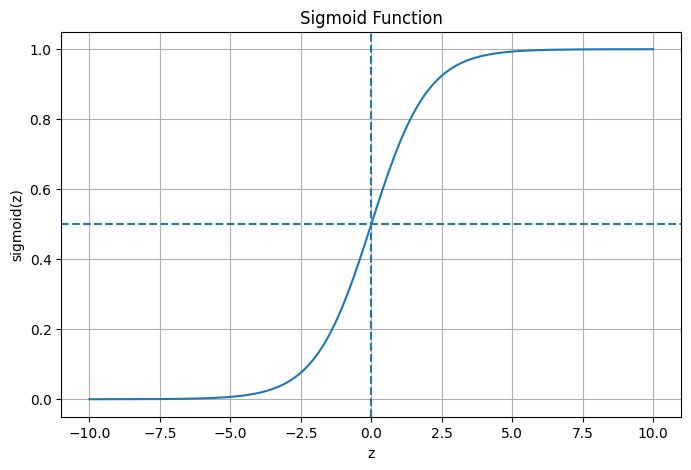

Observation: For very large positive or negative z values, the sigmoid curve becomes almost flat, so its gradient becomes very small and learning slows down.


In [ ]:
# ============================================================
# TASK 1 - BLOCK 4
# Plot Sigmoid
# ============================================================

z_values = np.linspace(-10, 10, 500)
sigmoid_values = sigmoid(z_values)

print("z_values shape:", z_values.shape)
print("sigmoid_values shape:", sigmoid_values.shape)

plt.figure(figsize=(8, 5))
plt.plot(z_values, sigmoid_values)
plt.axhline(0.5, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid Function")
plt.grid()
plt.show()

print(
    "Observation: For very large positive or negative z values, "
    "the sigmoid curve becomes almost flat, so its gradient becomes "
    "very small and learning slows down."
)

Task 2 – Forward Propagation and Cost  (15 marks)

In [ ]:
# ============================================================
# TASK 2 - BLOCK 1
# Initialization, Forward Propagation and Cost
# ============================================================

def initialize(n):
    w = np.zeros((n, 1))
    b = 0.0

    print("w shape:", w.shape)
    print("b:", b)

    return w, b


def forward(w, b, X):
    Z = np.dot(w.T, X) + b
    A = sigmoid(Z)

    assert Z.shape == (1, X.shape[1])
    assert A.shape == (1, X.shape[1])

    return A


def compute_cost(A, Y):
    m = Y.shape[1]

    cost = -(1 / m) * np.sum(
        Y * np.log(A + 1e-8)
        +
        (1 - Y) * np.log(1 - A + 1e-8)
    )

    cost = float(np.squeeze(cost))

    assert np.isscalar(cost)

    return cost

In [ ]:
# ============================================================
# TASK 2 - BLOCK 2
# Initial Cost
# ============================================================

n = X_train.shape[0]

w, b = initialize(n)

A_train_initial = forward(w, b, X_train)

initial_cost = compute_cost(A_train_initial, Y_train)

print("A shape:", A_train_initial.shape)
print("Initial cost:", initial_cost)

assert A_train_initial.shape == (1, 320)
assert np.isscalar(initial_cost)

w shape: (2, 1)
b: 0.0
A shape: (1, 320)
Initial cost: 0.6931471605599455


In [ ]:
# ============================================================
# TASK 2 - BLOCK 3
# Manual Verification of Initial Cost
# ============================================================

Z_manual = 0

A_manual = 1 / (1 + np.exp(-Z_manual))

cost_y1 = -np.log(A_manual)
cost_y0 = -np.log(1 - A_manual)

print("w = 0 and b = 0")
print("Z =", Z_manual)
print("A = sigmoid(0) =", A_manual)

print("Cost when Y = 1:", cost_y1)
print("Cost when Y = 0:", cost_y0)

print("-log(0.5) =", -np.log(0.5))

print(
    "0.6931 is the binary cross-entropy/log-loss when the model "
    "predicts probability 0.5 for every example."
)

w = 0 and b = 0
Z = 0
A = sigmoid(0) = 0.5
Cost when Y = 1: 0.6931471805599453
Cost when Y = 0: 0.6931471805599453
-log(0.5) = 0.6931471805599453
0.6931 is the binary cross-entropy/log-loss when the model predicts probability 0.5 for every example.


In [ ]:
# ============================================================
# TASK 2 - BLOCK 4
# np.log Guard
# ============================================================

A_example = np.array([[0.0, 1.0]])

with np.errstate(divide="ignore", invalid="ignore"):
    without_guard_1 = np.log(A_example)
    without_guard_2 = np.log(1 - A_example)

with_guard_1 = np.log(A_example + 1e-8)
with_guard_2 = np.log(1 - A_example + 1e-8)

print("Without guard:")
print("log(A):", without_guard_1)
print("log(1-A):", without_guard_2)

print("\nWith 1e-8 guard:")
print("log(A + 1e-8):", with_guard_1)
print("log(1-A + 1e-8):", with_guard_2)

print(
    "\nThe 1e-8 guard prevents log(0). Without it, log(0) gives "
    "-inf and may cause infinite or NaN cost values."
)

Without guard:
log(A): [[-inf   0.]]
log(1-A): [[  0. -inf]]

With 1e-8 guard:
log(A + 1e-8): [[-1.84206807e+01  9.99999989e-09]]
log(1-A + 1e-8): [[ 9.99999989e-09 -1.84206807e+01]]

The 1e-8 guard prevents log(0). Without it, log(0) gives -inf and may cause infinite or NaN cost values.


Task 3 – Backward Propagation and Gradient Checking  (20 marks)

In [ ]:
# ============================================================
# TASK 3 - BLOCK 1
# Backward Propagation
# ============================================================

def backward(X, A, Y):
    m = X.shape[1]

    dZ = A - Y

    dw = (1 / m) * np.dot(X, dZ.T)

    db = (1 / m) * np.sum(dZ)

    assert dZ.shape == (1, m)
    assert dw.shape == (X.shape[0], 1)
    assert np.isscalar(float(db))

    return dw, float(db)


w, b = initialize(X_train.shape[0])

A = forward(w, b, X_train)

dw, db = backward(X_train, A, Y_train)

print("w shape:", w.shape)
print("dw shape:", dw.shape)
print("db:", db)

assert dw.shape == w.shape

w shape: (2, 1)
b: 0.0
w shape: (2, 1)
dw shape: (2, 1)
db: -0.025


In [ ]:
# ============================================================
# TASK 3 - BLOCK 2
# Numerical Gradient Checking
# ============================================================

def gradient_check(X, Y, w, b, epsilon=1e-7):

    A = forward(w, b, X)

    dw, db = backward(X, A, Y)

    analytical_gradient = np.concatenate(
        [dw.reshape(-1), np.array([db])]
    )

    parameters = np.concatenate(
        [w.reshape(-1), np.array([b])]
    )

    numerical_gradient = np.zeros_like(parameters)

    for i in range(len(parameters)):

        theta_plus = parameters.copy()
        theta_minus = parameters.copy()

        theta_plus[i] += epsilon
        theta_minus[i] -= epsilon

        w_plus = theta_plus[:-1].reshape(w.shape)
        b_plus = theta_plus[-1]

        w_minus = theta_minus[:-1].reshape(w.shape)
        b_minus = theta_minus[-1]

        A_plus = forward(w_plus, b_plus, X)
        A_minus = forward(w_minus, b_minus, X)

        J_plus = compute_cost(A_plus, Y)
        J_minus = compute_cost(A_minus, Y)

        numerical_gradient[i] = (
            J_plus - J_minus
        ) / (2 * epsilon)

    numerator = np.linalg.norm(
        numerical_gradient - analytical_gradient
    )

    denominator = (
        np.linalg.norm(numerical_gradient)
        +
        np.linalg.norm(analytical_gradient)
    )

    relative_difference = numerator / (denominator + 1e-15)

    return (
        analytical_gradient,
        numerical_gradient,
        relative_difference
    )


np.random.seed(2)

w_check = np.random.randn(X_train.shape[0], 1) * 0.01
b_check = 0.01

analytical_grad, numerical_grad, difference = gradient_check(
    X_train,
    Y_train,
    w_check,
    b_check,
    epsilon=1e-7
)

print("Analytical gradient:")
print(analytical_grad)

print("\nNumerical gradient:")
print(numerical_grad)

print("\nRelative difference:", difference)

Analytical gradient:
[-0.25425471  0.171584   -0.02308228]

Numerical gradient:
[-0.25425471  0.171584   -0.02308228]

Relative difference: 1.0098970491954683e-08


In [ ]:
# ============================================================
# TASK 3 - BLOCK 3
# Gradient Check Result
# ============================================================

gradient_check_threshold = 1e-7

if difference < gradient_check_threshold:
    print("Gradient check PASSED")
else:
    print("Gradient check requires inspection")

print("Threshold:", gradient_check_threshold)

print(
    "Two-sided difference is used because it gives a more accurate "
    "derivative approximation than a one-sided difference."
)

Gradient check PASSED
Threshold: 1e-07
Two-sided difference is used because it gives a more accurate derivative approximation than a one-sided difference.


Task 4 – Training Loop and Evaluation  (20 marks)

In [ ]:
# ============================================================
# TASK 4 - BLOCK 1
# Logistic Regression Training Function
# ============================================================

def train(X, Y, iterations, learning_rate):

    n = X.shape[0]

    w, b = initialize(n)

    costs = []
    recorded_iterations = []

    for i in range(iterations):

        A = forward(w, b, X)

        cost = compute_cost(A, Y)

        dw, db = backward(X, A, Y)

        w = w - learning_rate * dw
        b = b - learning_rate * db

        if i % 100 == 0:
            costs.append(cost)
            recorded_iterations.append(i)

    return w, b, costs, recorded_iterations

In [ ]:
# ============================================================
# TASK 4 - BLOCK 2
# Train for 2000 Iterations, Learning Rate = 0.05
# ============================================================

w_logistic, b_logistic, logistic_costs, logistic_iterations = train(
    X_train,
    Y_train,
    iterations=2000,
    learning_rate=0.05
)

print("Final w shape:", w_logistic.shape)
print("Final b:", b_logistic)
print("Final recorded cost:", logistic_costs[-1])

w shape: (2, 1)
b: 0.0
Final w shape: (2, 1)
Final b: 0.37371778891092133
Final recorded cost: 0.3133293813873027


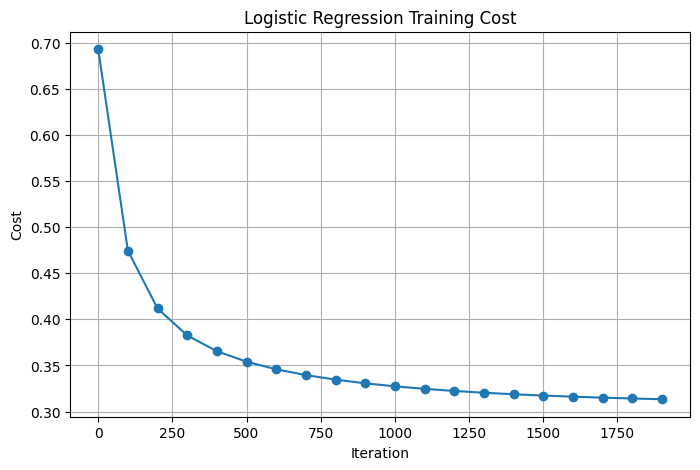

The decreasing cost curve indicates successful training.
A learning rate that is too high may cause the cost curve to oscillate strongly or increase/diverge.


In [ ]:
# ============================================================
# TASK 4 - BLOCK 3
# Plot Cost Curve
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    logistic_iterations,
    logistic_costs,
    marker="o"
)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Logistic Regression Training Cost")
plt.grid()
plt.show()

if logistic_costs[-1] < logistic_costs[0]:
    print(
        "The decreasing cost curve indicates successful training."
    )

print(
    "A learning rate that is too high may cause the cost curve "
    "to oscillate strongly or increase/diverge."
)

In [ ]:
# ============================================================
# TASK 4 - BLOCK 4
# Prediction and Accuracy
# ============================================================

def predict(w, b, X):

    A = forward(w, b, X)

    predictions = (A >= 0.5).astype(int)

    assert predictions.shape == (1, X.shape[1])

    return predictions


def accuracy(Y_true, Y_pred):

    return np.mean(Y_true == Y_pred) * 100


train_predictions_logistic = predict(
    w_logistic,
    b_logistic,
    X_train
)

test_predictions_logistic = predict(
    w_logistic,
    b_logistic,
    X_test
)

logistic_train_accuracy = accuracy(
    Y_train,
    train_predictions_logistic
)

logistic_test_accuracy = accuracy(
    Y_test,
    test_predictions_logistic
)

print(
    "Logistic Regression Training Accuracy:",
    logistic_train_accuracy,
    "%"
)

print(
    "Logistic Regression Test Accuracy:",
    logistic_test_accuracy,
    "%"
)

Logistic Regression Training Accuracy: 85.625 %
Logistic Regression Test Accuracy: 88.75 %


w shape: (2, 1)
b: 0.0
w shape: (2, 1)
b: 0.0
w shape: (2, 1)
b: 0.0
w shape: (2, 1)
b: 0.0


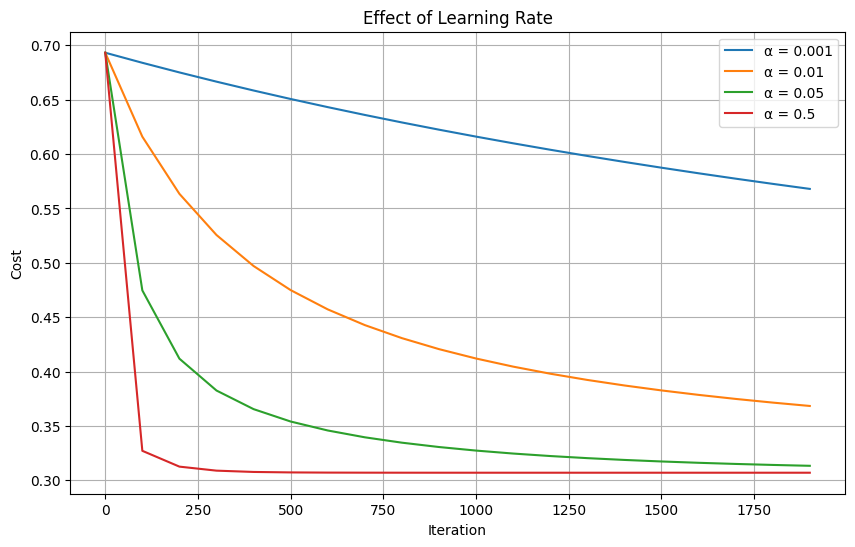

In [ ]:
# ============================================================
# TASK 4 - BLOCK 5
# Learning Rate Comparison
# ============================================================

learning_rates = [0.001, 0.01, 0.05, 0.5]

learning_rate_results = {}

plt.figure(figsize=(10, 6))

for lr in learning_rates:

    w_lr, b_lr, costs_lr, iterations_lr = train(
        X_train,
        Y_train,
        iterations=2000,
        learning_rate=lr
    )

    learning_rate_results[lr] = {
        "w": w_lr,
        "b": b_lr,
        "costs": costs_lr,
        "iterations": iterations_lr
    }

    plt.plot(
        iterations_lr,
        costs_lr,
        label=f"α = {lr}"
    )

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Effect of Learning Rate")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# ============================================================
# TASK 4 - BLOCK 6
# Learning Rate Observations
# ============================================================

for lr in learning_rates:

    costs_lr = learning_rate_results[lr]["costs"]

    print(
        f"α = {lr}: "
        f"Initial Cost = {costs_lr[0]:.6f}, "
        f"Final Cost = {costs_lr[-1]:.6f}"
    )


print(
    "\nα = 0.001: very slow learning."
)

print(
    "α = 0.01: faster learning than 0.001."
)

print(
    "α = 0.05: faster and stable convergence."
)

print(
    "α = 0.5: much larger update steps; observe the plotted "
    "curve for stability or oscillation."
)

α = 0.001: Initial Cost = 0.693147, Final Cost = 0.567938
α = 0.01: Initial Cost = 0.693147, Final Cost = 0.368351
α = 0.05: Initial Cost = 0.693147, Final Cost = 0.313329
α = 0.5: Initial Cost = 0.693147, Final Cost = 0.306966

α = 0.001: very slow learning.
α = 0.01: faster learning than 0.001.
α = 0.05: faster and stable convergence.
α = 0.5: much larger update steps; observe the plotted curve for stability or oscillation.


Task 5 – Two-Layer Neural Network  (25 marks)

In [ ]:
# ============================================================
# TASK 5 - BLOCK 1
# Initialize Two-Layer Neural Network
# ============================================================

def initialize_2layer(n_x, n_h, n_y):

    np.random.seed(2)

    W1 = np.random.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h, 1))

    W2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y, 1))

    parameters = {
        "W1": W1,
        "b1": b1,
        "W2": W2,
        "b2": b2
    }

    print("W1 shape:", W1.shape)
    print("b1 shape:", b1.shape)
    print("W2 shape:", W2.shape)
    print("b2 shape:", b2.shape)

    return parameters


print(
    "Weights must not all start at zero because hidden neurons "
    "would remain identical due to symmetry. Biases may start at zero "
    "because random weights already break the symmetry."
)

Weights must not all start at zero because hidden neurons would remain identical due to symmetry. Biases may start at zero because random weights already break the symmetry.


In [ ]:
# ============================================================
# TASK 5 - BLOCK 2
# Two-Layer Forward Propagation
# ============================================================

def forward_2layer(parameters, X):

    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]

    Z1 = W1 @ X + b1

    A1 = np.tanh(Z1)

    Z2 = W2 @ A1 + b2

    A2 = sigmoid(Z2)

    assert Z1.shape == (W1.shape[0], X.shape[1])
    assert A1.shape == Z1.shape

    assert Z2.shape == (1, X.shape[1])
    assert A2.shape == (1, X.shape[1])

    cache = {
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2
    }

    return A2, cache

In [ ]:
# ============================================================
# TASK 5 - BLOCK 3
# Two-Layer Backward Propagation
# ============================================================

def backward_2layer(
    parameters,
    cache,
    X,
    Y
):

    m = X.shape[1]

    W2 = parameters["W2"]

    A1 = cache["A1"]
    A2 = cache["A2"]

    dZ2 = A2 - Y

    dW2 = (1 / m) * (
        dZ2 @ A1.T
    )

    db2 = (1 / m) * np.sum(
        dZ2,
        axis=1,
        keepdims=True
    )

    dZ1 = (
        W2.T @ dZ2
    ) * (
        1 - np.power(A1, 2)
    )

    dW1 = (1 / m) * (
        dZ1 @ X.T
    )

    db1 = (1 / m) * np.sum(
        dZ1,
        axis=1,
        keepdims=True
    )

    gradients = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }

    return gradients

In [ ]:
# ============================================================
# TASK 5 - BLOCK 4
# Parameter Update
# ============================================================

def update_2layer(
    parameters,
    gradients,
    learning_rate
):

    parameters["W1"] = (
        parameters["W1"]
        - learning_rate * gradients["dW1"]
    )

    parameters["b1"] = (
        parameters["b1"]
        - learning_rate * gradients["db1"]
    )

    parameters["W2"] = (
        parameters["W2"]
        - learning_rate * gradients["dW2"]
    )

    parameters["b2"] = (
        parameters["b2"]
        - learning_rate * gradients["db2"]
    )

    return parameters

In [ ]:
# ============================================================
# TASK 5 - BLOCK 5
# Train Two-Layer Network
# ============================================================

def train_2layer(
    X,
    Y,
    n_h,
    iterations=5000,
    learning_rate=0.5,
    print_cost=False
):

    n_x = X.shape[0]
    n_y = Y.shape[0]

    parameters = initialize_2layer(
        n_x,
        n_h,
        n_y
    )

    costs = []
    recorded_iterations = []

    for i in range(iterations):

        A2, cache = forward_2layer(
            parameters,
            X
        )

        cost = compute_cost(
            A2,
            Y
        )

        gradients = backward_2layer(
            parameters,
            cache,
            X,
            Y
        )

        parameters = update_2layer(
            parameters,
            gradients,
            learning_rate
        )

        if i % 100 == 0:

            costs.append(cost)
            recorded_iterations.append(i)

            if print_cost:
                print(
                    f"Iteration {i}: "
                    f"Cost = {cost:.6f}"
                )

    return (
        parameters,
        costs,
        recorded_iterations
    )

In [ ]:
# ============================================================
# TASK 5 - BLOCK 6
# Train n_h = 4
# ============================================================

parameters_4, nn_costs_4, nn_iterations_4 = train_2layer(
    X_train,
    Y_train,
    n_h=4,
    iterations=5000,
    learning_rate=0.5,
    print_cost=True
)

print(
    "Final recorded cost:",
    nn_costs_4[-1]
)

W1 shape: (4, 2)
b1 shape: (4, 1)
W2 shape: (1, 4)
b2 shape: (1, 1)
Iteration 0: Cost = 0.693001
Iteration 100: Cost = 0.313576
Iteration 200: Cost = 0.310689
Iteration 300: Cost = 0.309371
Iteration 400: Cost = 0.308315
Iteration 500: Cost = 0.307406
Iteration 600: Cost = 0.306581
Iteration 700: Cost = 0.305787
Iteration 800: Cost = 0.304974
Iteration 900: Cost = 0.304069
Iteration 1000: Cost = 0.302859
Iteration 1100: Cost = 0.300049
Iteration 1200: Cost = 0.289200
Iteration 1300: Cost = 0.253296
Iteration 1400: Cost = 0.180463
Iteration 1500: Cost = 0.129505
Iteration 1600: Cost = 0.104272
Iteration 1700: Cost = 0.090694
Iteration 1800: Cost = 0.082518
Iteration 1900: Cost = 0.077151
Iteration 2000: Cost = 0.073395
Iteration 2100: Cost = 0.070640
Iteration 2200: Cost = 0.068544
Iteration 2300: Cost = 0.066904
Iteration 2400: Cost = 0.065591
Iteration 2500: Cost = 0.064519
Iteration 2600: Cost = 0.063630
Iteration 2700: Cost = 0.062881
Iteration 2800: Cost = 0.062243
Iteration 2900: 

In [ ]:
# ============================================================
# TASK 5 - BLOCK 7
# Two-Layer Prediction
# ============================================================

def predict_2layer(
    parameters,
    X
):

    A2, _ = forward_2layer(
        parameters,
        X
    )

    predictions = (
        A2 >= 0.5
    ).astype(int)

    return predictions

In [ ]:
# ============================================================
# TASK 5 - BLOCK 8
# Two-Layer Accuracy
# ============================================================

train_predictions_nn = predict_2layer(
    parameters_4,
    X_train
)

test_predictions_nn = predict_2layer(
    parameters_4,
    X_test
)

nn_train_accuracy = accuracy(
    Y_train,
    train_predictions_nn
)

nn_test_accuracy = accuracy(
    Y_test,
    test_predictions_nn
)

print(
    "Logistic Regression Training Accuracy:",
    f"{logistic_train_accuracy:.2f}%"
)

print(
    "Logistic Regression Test Accuracy:",
    f"{logistic_test_accuracy:.2f}%"
)

print(
    "Two-Layer NN Training Accuracy:",
    f"{nn_train_accuracy:.2f}%"
)

print(
    "Two-Layer NN Test Accuracy:",
    f"{nn_test_accuracy:.2f}%"
)

if nn_test_accuracy > logistic_test_accuracy:
    print(
        "The two-layer neural network performs better because "
        "its hidden layer can learn a nonlinear decision boundary."
    )
else:
    print(
        "The measured accuracies are shown above for comparison."
    )

Logistic Regression Training Accuracy: 85.62%
Logistic Regression Test Accuracy: 88.75%
Two-Layer NN Training Accuracy: 97.81%
Two-Layer NN Test Accuracy: 93.75%
The two-layer neural network performs better because its hidden layer can learn a nonlinear decision boundary.


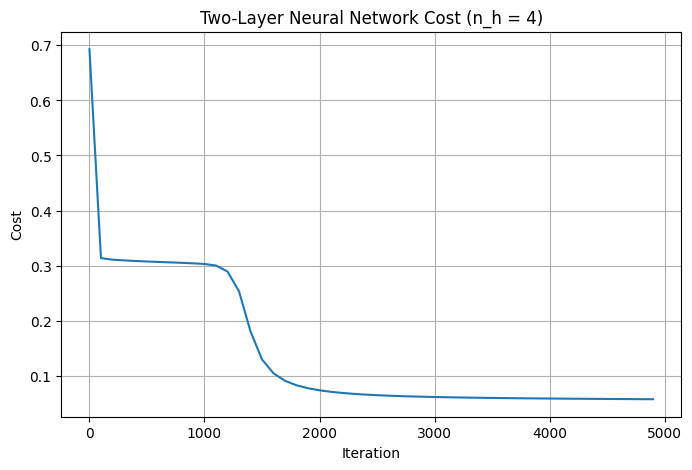

In [ ]:
# ============================================================
# TASK 5 - BLOCK 9
# Plot NN Training Cost
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    nn_iterations_4,
    nn_costs_4
)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title(
    "Two-Layer Neural Network Cost "
    "(n_h = 4)"
)
plt.grid()
plt.show()


In [ ]:
# ============================================================
# TASK 5 - BLOCK 10
# Decision Boundary Helper
# ============================================================

def plot_decision_boundary(
    model,
    X_data,
    Y_data,
    title
):

    x_min = (
        X_data[0].min() - 0.5
    )

    x_max = (
        X_data[0].max() + 0.5
    )

    y_min = (
        X_data[1].min() - 0.5
    )

    y_max = (
        X_data[1].max() + 0.5
    )

    xx, yy = np.meshgrid(
        np.linspace(
            x_min,
            x_max,
            400
        ),
        np.linspace(
            y_min,
            y_max,
            400
        )
    )

    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ].T

    Z = model(grid)

    Z = Z.reshape(xx.shape)

    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.3,
        cmap="bwr"
    )

    plt.scatter(
        X_data[0],
        X_data[1],
        c=Y_data.ravel(),
        cmap="bwr",
        edgecolors="k"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)

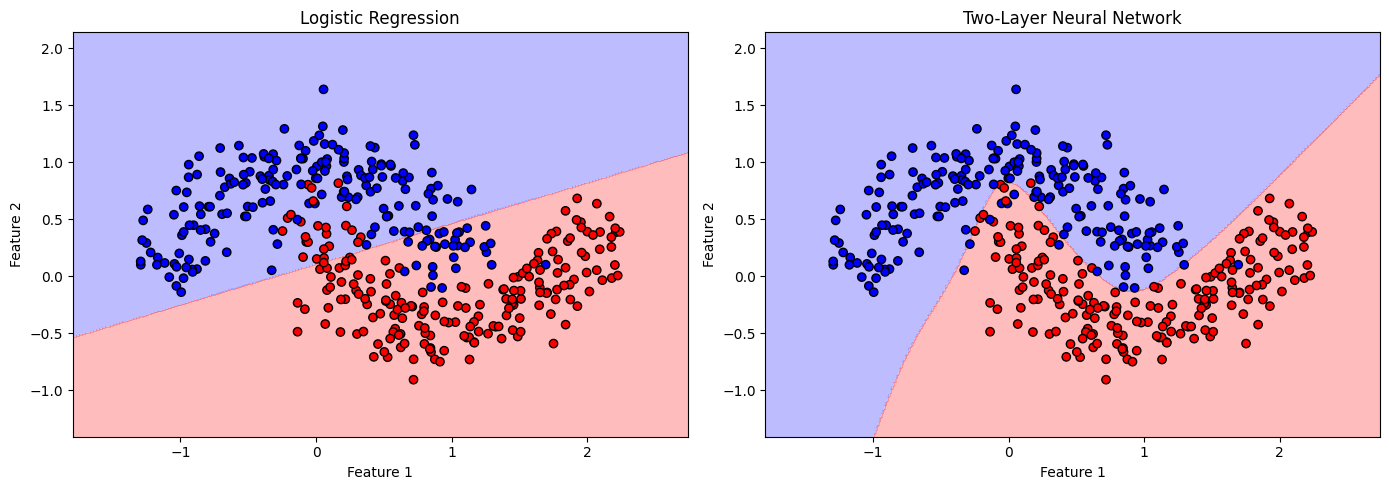

Logistic regression produces a linear decision boundary, while the hidden-layer neural network can learn a curved nonlinear boundary that follows the two-moons pattern.


In [ ]:
# ============================================================
# TASK 5 - BLOCK 11
# Logistic vs Two-Layer Decision Boundaries
# ============================================================

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

plot_decision_boundary(
    lambda grid: predict(
        w_logistic,
        b_logistic,
        grid
    ).ravel(),
    X,
    Y,
    "Logistic Regression"
)

plt.subplot(1, 2, 2)

plot_decision_boundary(
    lambda grid: predict_2layer(
        parameters_4,
        grid
    ).ravel(),
    X,
    Y,
    "Two-Layer Neural Network"
)

plt.tight_layout()
plt.show()

print(
    "Logistic regression produces a linear decision boundary, "
    "while the hidden-layer neural network can learn a curved "
    "nonlinear boundary that follows the two-moons pattern."
)

In [ ]:
# ============================================================
# TASK 5 - BLOCK 12
# Verify keepdims=True
# ============================================================

A2_temp, cache_temp = forward_2layer(
    parameters_4,
    X_train
)

m = X_train.shape[1]

W2_temp = parameters_4["W2"]

A1_temp = cache_temp["A1"]

dZ2_temp = (
    A2_temp - Y_train
)

db2_keepdims = (
    (1 / m)
    * np.sum(
        dZ2_temp,
        axis=1,
        keepdims=True
    )
)

db2_no_keepdims = (
    (1 / m)
    * np.sum(
        dZ2_temp,
        axis=1
    )
)

dZ1_temp = (
    W2_temp.T @ dZ2_temp
) * (
    1 - np.power(
        A1_temp,
        2
    )
)

db1_keepdims = (
    (1 / m)
    * np.sum(
        dZ1_temp,
        axis=1,
        keepdims=True
    )
)

db1_no_keepdims = (
    (1 / m)
    * np.sum(
        dZ1_temp,
        axis=1
    )
)

print(
    "db1 with keepdims:",
    db1_keepdims.shape
)

print(
    "db1 without keepdims:",
    db1_no_keepdims.shape
)

print(
    "db2 with keepdims:",
    db2_keepdims.shape
)

print(
    "db2 without keepdims:",
    db2_no_keepdims.shape
)

wrong_b1_update = (
    parameters_4["b1"]
    - 0.5 * db1_no_keepdims
)

print(
    "b1 original shape:",
    parameters_4["b1"].shape
)

print(
    "Shape after update without keepdims:",
    wrong_b1_update.shape
)

print(
    "keepdims=True preserves the required column-vector bias shape."
)

db1 with keepdims: (4, 1)
db1 without keepdims: (4,)
db2 with keepdims: (1, 1)
db2 without keepdims: (1,)
b1 original shape: (4, 1)
Shape after update without keepdims: (4, 4)
keepdims=True preserves the required column-vector bias shape.


In [ ]:
# ============================================================
# TASK 6 - BLOCK 1
# Hidden Layer Size Experiment
# ============================================================

hidden_sizes = [
    1,
    2,
    4,
    10,
    50
]

hidden_results = {}

for n_h in hidden_sizes:

    print(
        "\nTraining n_h =",
        n_h
    )

    parameters_h, costs_h, iterations_h = train_2layer(
        X_train,
        Y_train,
        n_h=n_h,
        iterations=5000,
        learning_rate=0.5,
        print_cost=False
    )

    train_pred_h = predict_2layer(
        parameters_h,
        X_train
    )

    test_pred_h = predict_2layer(
        parameters_h,
        X_test
    )

    train_acc_h = accuracy(
        Y_train,
        train_pred_h
    )

    test_acc_h = accuracy(
        Y_test,
        test_pred_h
    )

    A2_final_h, _ = forward_2layer(
        parameters_h,
        X_train
    )

    final_cost_h = compute_cost(
        A2_final_h,
        Y_train
    )

    hidden_results[n_h] = {
        "parameters": parameters_h,
        "cost": final_cost_h,
        "train_accuracy": train_acc_h,
        "test_accuracy": test_acc_h,
        "costs": costs_h,
        "iterations": iterations_h
    }


Training n_h = 1
W1 shape: (1, 2)
b1 shape: (1, 1)
W2 shape: (1, 1)
b2 shape: (1, 1)

Training n_h = 2
W1 shape: (2, 2)
b1 shape: (2, 1)
W2 shape: (1, 2)
b2 shape: (1, 1)

Training n_h = 4
W1 shape: (4, 2)
b1 shape: (4, 1)
W2 shape: (1, 4)
b2 shape: (1, 1)

Training n_h = 10
W1 shape: (10, 2)
b1 shape: (10, 1)
W2 shape: (1, 10)
b2 shape: (1, 1)

Training n_h = 50
W1 shape: (50, 2)
b1 shape: (50, 1)
W2 shape: (1, 50)
b2 shape: (1, 1)


In [ ]:
# ============================================================
# TASK 6 - BLOCK 2
# Results Table
# ============================================================

print(
    f"{'n_h':<10}"
    f"{'Final Cost':<20}"
    f"{'Train Accuracy':<20}"
    f"{'Test Accuracy':<20}"
)

print("-" * 70)

for n_h in hidden_sizes:

    result = hidden_results[n_h]

    print(
        f"{n_h:<10}"
        f"{result['cost']:<20.6f}"
        f"{result['train_accuracy']:<20.2f}"
        f"{result['test_accuracy']:<20.2f}"
    )

n_h       Final Cost          Train Accuracy      Test Accuracy       
----------------------------------------------------------------------
1         0.309637            86.25               91.25               
2         0.270187            85.94               90.00               
4         0.057078            97.81               93.75               
10        0.067978            97.19               92.50               
50        0.296651            86.25               90.00               


In [ ]:
# ============================================================
# TASK 6 - BLOCK 3
# Find Best Hidden Layer Size
# ============================================================

best_n_h = max(
    hidden_sizes,
    key=lambda h:
    hidden_results[h]["test_accuracy"]
)

print(
    "Best hidden layer size based on test accuracy:",
    best_n_h
)

print(
    "Best test accuracy:",
    hidden_results[best_n_h]["test_accuracy"]
)

Best hidden layer size based on test accuracy: 4
Best test accuracy: 93.75


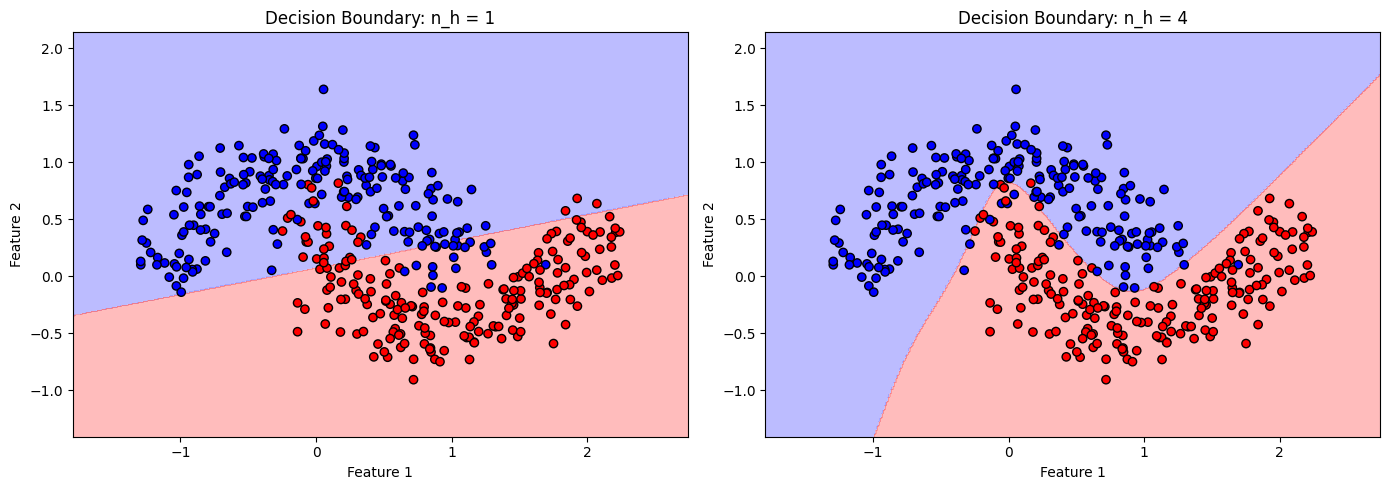

With n_h = 1, the network has very limited capacity to represent the curved two-moons decision boundary.
With n_h = 4, the network can represent a more complex nonlinear boundary.


In [ ]:
# ============================================================
# TASK 6 - BLOCK 4
# Decision Boundary for n_h = 1 and Best n_h
# ============================================================

parameters_nh1 = hidden_results[1]["parameters"]

parameters_best = hidden_results[
    best_n_h
]["parameters"]

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

plot_decision_boundary(
    lambda grid: predict_2layer(
        parameters_nh1,
        grid
    ).ravel(),
    X,
    Y,
    "Decision Boundary: n_h = 1"
)

plt.subplot(1, 2, 2)

plot_decision_boundary(
    lambda grid: predict_2layer(
        parameters_best,
        grid
    ).ravel(),
    X,
    Y,
    f"Decision Boundary: n_h = {best_n_h}"
)

plt.tight_layout()
plt.show()

print(
    "With n_h = 1, the network has very limited capacity to "
    "represent the curved two-moons decision boundary."
)

print(
    f"With n_h = {best_n_h}, the network can represent a more "
    "complex nonlinear boundary."
)

In [ ]:
# ============================================================
# TASK 6 - BLOCK 5
# Larger Hidden Layer Performance
# ============================================================

large_hidden_sizes = [
    h for h in hidden_sizes
    if h >= 10
]

worse_large_n_h = min(
    large_hidden_sizes,
    key=lambda h:
    hidden_results[h]["test_accuracy"]
)

print(
    "Larger hidden layer with the lower test performance:",
    worse_large_n_h
)

print(
    "Training Accuracy:",
    hidden_results[worse_large_n_h][
        "train_accuracy"
    ]
)

print(
    "Test Accuracy:",
    hidden_results[worse_large_n_h][
        "test_accuracy"
    ]
)

print(
    "A possible reason is optimization sensitivity: with more "
    "parameters, the same initialization scale and learning rate "
    "may make gradient-descent optimization harder or lead to a "
    "poorer local solution. The lower performance is therefore "
    "not necessarily caused by overfitting."
)

Larger hidden layer with the lower test performance: 50
Training Accuracy: 86.25
Test Accuracy: 90.0
A possible reason is optimization sensitivity: with more parameters, the same initialization scale and learning rate may make gradient-descent optimization harder or lead to a poorer local solution. The lower performance is therefore not necessarily caused by overfitting.
